In [33]:
# Import required libraries

import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,  f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from collections import Counter

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [34]:
# Load the latest version of the dataset directly into a pandas DataFrame
file_path = r"C:\Users\mail2\OneDrive\Desktop\MY_DRIVE\MLOps\MLOps-Addy\Data_Sets\election_dataset_updated.csv"
dataset = pd.read_csv(file_path)
dataset.tail(15)

,Year,Party_ID,Party_Logo,Is_Candidate_Celebrity,Celebrity_Support,Alliance,Campaign,Opinion_Poll,Verdict
61,2015,BMK,Square,no,Yes,LMK,31.7,49.6,Succeeded
62,2015,AMK,Rectangle,yes,Yes,KMK,41.0,57.6,Failed
63,2015,CMK,Triangle,no,no,JMK,40.2,28.9,Failed
64,2018,INC,Circle,no,no,KMK,39.4,32.0,Failed
65,2018,BMK,Square,no,Yes,LMK,44.0,61.2,Succeeded
66,2018,AMK,Rectangle,yes,Yes,NMK,48.6,68.2,Failed
67,2018,CMK,Triangle,no,no,JMK,44.9,28.6,Failed
68,2021,INC,Circle,no,no,NMK,57.2,60.1,Failed
69,2021,BMK,Square,no,Yes,LMK,55.1,66.0,Succeeded
70,2021,AMK,Rectangle,yes,Yes,KMK,43.9,60.8,Failed


In [35]:
# Data analysis
print("Dataset Shape:", dataset.shape)
print("Dataset Info:")
print(dataset.info())
print(dataset.describe())

Dataset Shape: (76, 9)
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    76 non-null     int64  
 1   Party_ID                76 non-null     object 
 2   Party_Logo              76 non-null     object 
 3   Is_Candidate_Celebrity  76 non-null     object 
 4   Celebrity_Support       76 non-null     object 
 5   Alliance                76 non-null     object 
 6   Campaign                76 non-null     float64
 7   Opinion_Poll            76 non-null     float64
 8   Verdict                 76 non-null     object 
dtypes: float64(2), int64(1), object(6)
memory usage: 5.5+ KB
None
              Year   Campaign  Opinion_Poll
count    76.000000  76.000000     76.000000
mean   1997.000000  36.107895     38.752632
std      16.540859  10.497552     16.908242
min    1970.000000  10.500000      

In [36]:
# Encoding categorical values
label_encoders = {}
for column in dataset.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    dataset[column] = le.fit_transform(dataset[column])
    label_encoders[column] = le
print("Encoded Dataset Sample:")
print(dataset.head())


Encoded Dataset Sample:
   Year  Party_ID  Party_Logo  Is_Candidate_Celebrity  Celebrity_Support  \
0  1970         3           0                       0                  1   
1  1970         1           2                       0                  1   
2  1970         0           1                       0                  1   
3  1970         2           3                       0                  1   
4  1973         3           0                       0                  1   

   Alliance  Campaign  Opinion_Poll  Verdict  
0         2      34.6          45.0        1  
1         3      41.2          48.9        0  
2         1      26.4           9.3        0  
3         0      22.1          19.4        0  
4         1      29.1          41.3        1  


In [37]:
scaler = StandardScaler().fit_transform(dataset.loc[:,dataset.columns!='Verdict'])
scaled_data = scaler[0:40000]
df = pd.DataFrame(data=scaled_data)
X = dataset.drop(columns=['Verdict'])  
y = dataset['Verdict']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (76, 8)
Target Shape: (76,)


In [38]:
# Detect outliers using Isolation Forest
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outliers = iso_forest.fit_predict(X)
print("Outlier Detection Complete. Number of outliers detected:", np.sum(outliers == -1))
# Print all the outliers
print(X[outliers == -1])
# Remove outliers from the dataset
# mask = outliers != -1
# X, y = X[mask], y[mask]
print("Dataset shape after outlier removal:", X.shape, y.shape)



Outlier Detection Complete. Number of outliers detected: 1
    Year  Party_ID  Party_Logo  Is_Candidate_Celebrity  Celebrity_Support  \
68  2021         3           0                       0                  1   

    Alliance  Campaign  Opinion_Poll  
68         3      57.2          60.1  
Dataset shape after outlier removal: (76, 8) (76,)


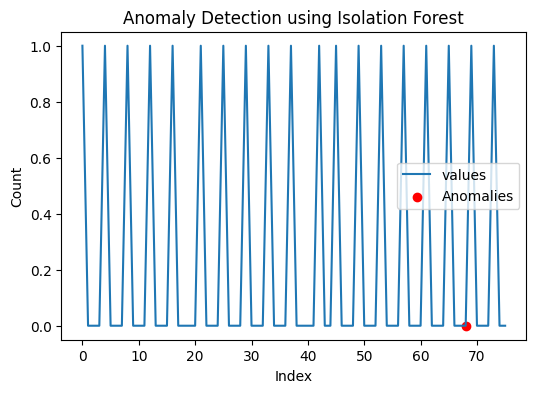

In [39]:
# Visualize Anamoly Detection Results
plt.figure(figsize=(6,4))
plt.plot(dataset.index, dataset['Verdict'],label='values')
plt.scatter(X.index[outliers == -1], dataset['Verdict'][outliers == -1], color='red', label='Anomalies')
plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('Index')
plt.ylabel('Count')
plt.legend()
plt.show()

In [40]:
# Detect anaomalies using Z-score
from scipy import stats
z_scores = np.abs(stats.zscore(X))
threshold = 3
outliers_z = np.where(z_scores > threshold)
print("Z-score Anomaly Detection Complete. Number of outliers detected:", len(outliers_z[0]))
# Print all the outliers
print(X.iloc[outliers_z[0]])


Z-score Anomaly Detection Complete. Number of outliers detected: 0
Empty DataFrame
Columns: [Year, Party_ID, Party_Logo, Is_Candidate_Celebrity, Celebrity_Support, Alliance, Campaign, Opinion_Poll]
Index: []


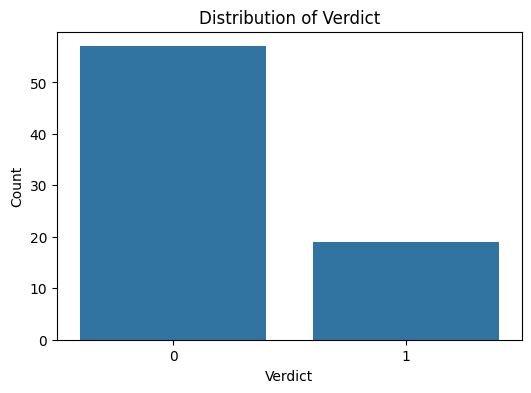

In [41]:
# Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(x='Verdict', data=dataset)
plt.title('Distribution of Verdict')
plt.xlabel('Verdict')
plt.ylabel('Count')
plt.show()

In [42]:
# Check for imbalanced data
counter = Counter(y)
print("Class Distribution:", counter)
# Print only if imbalanced
if max(counter.values()) / min(counter.values()) > 1.5:
    print("The dataset is imbalanced.")
else:
    print("The dataset is balanced.")
    


Class Distribution: Counter({0: 57, 1: 19})
The dataset is imbalanced.


In [43]:
# Separate windows and horizons 
for i in range(1,4):
    dataset[f'lag_{i}'] = dataset['Verdict'].shift(i)
    print(f"Created lag feature: lag_{i}")
    print(dataset[[f'lag_{i}']].head())



Created lag feature: lag_1
   lag_1
0    NaN
1    1.0
2    0.0
3    0.0
4    0.0
Created lag feature: lag_2
   lag_2
0    NaN
1    NaN
2    1.0
3    0.0
4    0.0
Created lag feature: lag_3
   lag_3
0    NaN
1    NaN
2    NaN
3    1.0
4    0.0


In [44]:
dataset.head()

,Year,Party_ID,Party_Logo,Is_Candidate_Celebrity,Celebrity_Support,Alliance,Campaign,Opinion_Poll,Verdict,lag_1,lag_2,lag_3
0,1970,3,0,0,1,2,34.6,45.0,1,NaN,NaN,NaN
1,1970,1,2,0,1,3,41.2,48.9,0,1.0,NaN,NaN
2,1970,0,1,0,1,1,26.4,9.3,0,0.0,1.0,NaN
3,1970,2,3,0,1,0,22.1,19.4,0,0.0,0.0,1.0
4,1973,3,0,0,1,1,29.1,41.3,1,0.0,0.0,0.0


In [45]:
dataset=dataset.dropna()
dataset.head()

,Year,Party_ID,Party_Logo,Is_Candidate_Celebrity,Celebrity_Support,Alliance,Campaign,Opinion_Poll,Verdict,lag_1,lag_2,lag_3
3,1970,2,3,0,1,0,22.1,19.4,0,0.0,0.0,1.0
4,1973,3,0,0,1,1,29.1,41.3,1,0.0,0.0,0.0
5,1973,1,2,0,1,3,22.4,21.0,0,1.0,0.0,0.0
6,1973,0,1,0,1,2,39.0,3.6,0,0.0,1.0,0.0
7,1973,2,3,0,1,0,21.9,18.1,0,0.0,0.0,1.0


In [46]:
# Define train size and test size
train_size = int(len(dataset) * 0.8)
train, test = dataset.iloc[:train_size], dataset.iloc[train_size:]
print("Train size:", train_size)
print("Test size:", len(dataset) - train_size)
train = pd.DataFrame(train)
test = pd.DataFrame(test)
print(train)
print(test)


Train size: 58
Test size: 15
    Year  Party_ID  Party_Logo  Is_Candidate_Celebrity  Celebrity_Support  \
3   1970         2           3                       0                  1   
4   1973         3           0                       0                  1   
5   1973         1           2                       0                  1   
6   1973         0           1                       0                  1   
7   1973         2           3                       0                  1   
8   1976         3           0                       0                  1   
9   1976         1           2                       0                  1   
10  1976         0           1                       0                  1   
11  1976         2           3                       0                  1   
12  1979         3           0                       0                  1   
13  1979         1           2                       0                  1   
14  1979         0           1                 

In [47]:
# Initialize Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = model.predict(X_test)
print(y_pred)
# Make Predections
y_pred = model.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred, average='weighted'))
# print("Recall:", recall_score(y_test, y_pred, average='weighted'))
# print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
# print("Classification Report:\n", classification_report(y_test, y_pred))




[ 0.12358595 -0.10902451  0.11292512  0.07729387  0.79092899  0.06384591
  0.85701395  0.80771596  0.0349775   0.0818415  -0.05612225  0.10943506
  0.17080912  0.08928452  0.07404085  0.72107453  0.25013754  0.1476173
 -0.11627231 -0.25430027 -0.13831773 -0.00573379 -0.1353793   0.04564062
 -0.01305522  0.07581476  0.18275509  0.02063075  0.09566331  0.04394388
  0.15505346  0.79494875  0.17003441  0.07430668  0.00551727  0.70087818
 -0.02573727  0.24485952]
